In [1]:
import os
import sys
module_path = os.path.abspath(os.path.join('..'))
grandparent_module_path = os.path.abspath(os.path.join('../..'))
if module_path not in sys.path:
    sys.path.append(module_path)
    sys.path.append(grandparent_module_path)

from pathlib import Path
import jax
import jax.numpy as jnp
from flax.training import checkpoints
from flax import serialization
from agents.a2c_rnn_flax import A2CRNNFlax, init_network_and_params
from environments.components.train_state import create_train_state
from environments.treadmill_env_jax import treadmill_session_default_params
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# --- CONFIGURATION ---
CHECKPOINT_PATH = "../../checkpoints/vanilla_n5_exp_fixed_pred_all_tau_seed_8001_seed_8001_2025-11-06_18:51:28.993873/checkpoint_2500"
HIDDEN_SIZE = 5
ACTION_SIZE = 2
OBS_SIZE = 4
RNN_TYPE = "VANILLA"
VAR_NOISE = 1e-4
LEARNING_RATE = 2.5e-5
SEED = 0
NUM_ENVS = 1

In [3]:
# --- INITIALIZE NETWORK + TRAIN STATE ---
rng_key = jax.random.key(SEED)
net_init_key, rng_key = jax.random.split(rng_key)

network, params = init_network_and_params(
    hidden_size=HIDDEN_SIZE,
    action_size=ACTION_SIZE,
    obs_size=OBS_SIZE,
    rnn_type=RNN_TYPE,
    var_noise=VAR_NOISE,
    rng_key=net_init_key,
)

train_state = create_train_state(
    rng_key=rng_key,
    obs_size=OBS_SIZE,
    hidden_size=HIDDEN_SIZE,
    num_envs=NUM_ENVS,
    learning_rate=LEARNING_RATE,
    params=params,
)

# --- LOAD CHECKPOINT ---
print(f"Loading checkpoint from {CHECKPOINT_PATH} ...")
ckpt_path = Path(CHECKPOINT_PATH).resolve()

restored = checkpoints.restore_checkpoint(ckpt_dir=ckpt_path, target=None)
if "params" in restored:
    params = restored["params"]
else:
    params = restored
train_state = train_state.replace(params=params)
print("Model loaded successfully!")

# --- PROBE WEIGHTS ---
# For example, list top-level parameter shapes:
flat_params = jax.tree_util.tree_map(lambda x: x.shape, train_state.params)
print("\nParameter shapes:")
print(flat_params)

# Example: access specific weights
# e.g. actor dense layer kernel:
try:
    print("\nActor dense kernel sample:")
    print(train_state.params['actor_dense']['kernel'][:3, :3])
except KeyError:
    print("Could not find 'actor_dense' in params; inspect `flat_params` keys to locate structure.")

Loading checkpoint from ../../checkpoints/vanilla_n5_exp_fixed_pred_all_tau_seed_8001_seed_8001_2025-11-06_18:51:28.993873/checkpoint_2500 ...
Model loaded successfully!

Parameter shapes:
{'params': {'actor': {'bias': (2,), 'kernel': (5, 2)}, 'critic': {'bias': (1,), 'kernel': (5, 1)}, 'env_quality_prediction': {'bias': (3,), 'kernel': (5, 3)}, 'rnn_actor': {'hidden_projection': {'bias': (5,), 'kernel': (5, 5)}, 'input_projection': {'kernel': (7, 5)}}, 'rnn_critic': {'hidden_projection': {'bias': (5,), 'kernel': (5, 5)}, 'input_projection': {'kernel': (7, 5)}}}}

Actor dense kernel sample:
Could not find 'actor_dense' in params; inspect `flat_params` keys to locate structure.


/home/david.bell/anaconda3/envs/favorably_connected/lib/python3.11/site-packages/orbax/checkpoint/_src/serialization/type_handlers.py:1269: UserWarning: Sharding info not provided when restoring. Populating sharding info from sharding file. Please note restoration time will be slightly increased due to reading from file. Note also that this option is unsafe when restoring on a different topology than the checkpoint was saved with.
  warnings.warn(


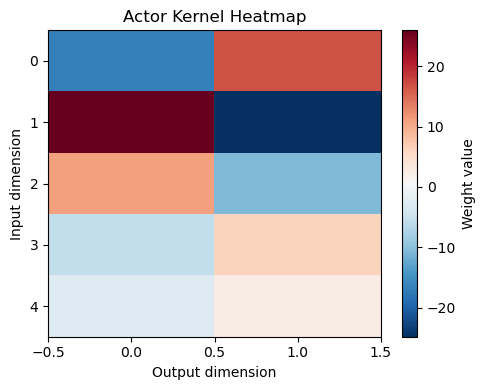

In [6]:
# Plot 1: Actor kernel heatmap
plt.figure(figsize=(5, 4))
plt.imshow(params['params']['actor']['kernel'], aspect='auto', cmap='RdBu_r')
plt.colorbar(label='Weight value')
plt.title('Actor Kernel Heatmap')
plt.xlabel('Output dimension')
plt.ylabel('Input dimension')
plt.tight_layout()

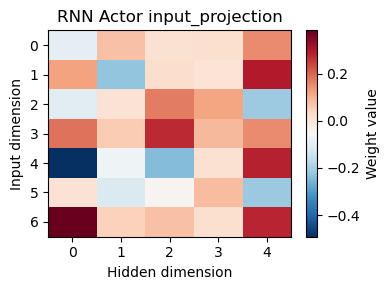

In [10]:
# Plot 3: All 'in' gates for rnn_actor
# RNN typically has multiple gate types, we're plotting all the 'in' gates
fig, axes = plt.subplots(1, 1, figsize=(4, 3))
axes = [axes]

# Get all the 'in' gate kernels from rnn_critic
in_keys = ['input_projection']  # Based on your parameter structure
titles = ['input_projection']

for idx, (key, title) in enumerate(zip(in_keys, titles)):
    if key in params['params']['rnn_actor']:
        kernel = params['params']['rnn_actor'][key]['kernel']
        im = axes[idx].imshow(kernel, aspect='auto', cmap='RdBu_r')
        axes[idx].set_title(f'RNN Actor {title}')
        axes[idx].set_xlabel('Hidden dimension')
        axes[idx].set_ylabel('Input dimension')
        plt.colorbar(im, ax=axes[idx], label='Weight value')

plt.tight_layout()

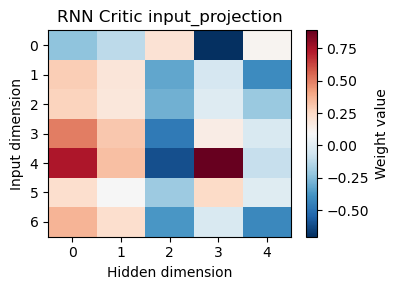

In [12]:
# Plot 3: All 'in' gates for rnn_actor
# RNN typically has multiple gate types, we're plotting all the 'in' gates
fig, axes = plt.subplots(1, 1, figsize=(4, 3))
axes = [axes]

# Get all the 'in' gate kernels from rnn_critic
in_keys = ['input_projection']  # Based on your parameter structure
titles = ['input_projection']

for idx, (key, title) in enumerate(zip(in_keys, titles)):
    if key in params['params']['rnn_critic']:
        kernel = params['params']['rnn_critic'][key]['kernel']
        im = axes[idx].imshow(kernel, aspect='auto', cmap='RdBu_r')
        axes[idx].set_title(f'RNN Critic {title}')
        axes[idx].set_xlabel('Hidden dimension')
        axes[idx].set_ylabel('Input dimension')
        plt.colorbar(im, ax=axes[idx], label='Weight value')

plt.tight_layout()

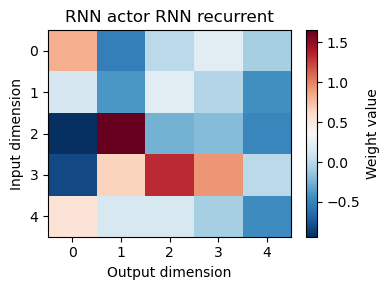

In [25]:
# Plot 3: All 'in' gates for rnn_actor
# RNN typically has multiple gate types, we're plotting all the 'in' gates
fig, axes = plt.subplots(1, 1, figsize=(4, 3))

# Get all the 'in' gate kernels from rnn_critic
title = 'RNN recurrent'

kernel = params['params']['rnn_actor']['hidden_projection']['kernel']
im = axes.imshow(kernel, aspect='auto', cmap='RdBu_r')
axes.set_title(f'RNN actor {title}')
axes.set_xlabel('Output dimension')
axes.set_ylabel('Input dimension')
plt.colorbar(im, ax=axes, label='Weight value')

plt.tight_layout()

In [18]:
dir_path = '../../results/vanilla_n5_exp_fixed_pred_all_tau_seed_8001_seed_2000_2025-11-06_21:01:34.249761/trajectories_20251106_210236.pkl'

In [19]:
from nb_analysis_tools import load_trajectory_data, parse_behavioral_data
import numpy as np
from sklearn.decomposition import PCA

traj_data = {}

for env_idx in range(15):
    traj_data_raw = load_trajectory_data(dir_path)
    traj_data_env = parse_behavioral_data(traj_data_raw[env_idx])
    for key in traj_data_env.keys():
        if key in traj_data:
            traj_data[key] = np.concatenate([traj_data[key], traj_data_env[key]], axis=0)
        else:
            traj_data[key] = traj_data_env[key]
    
pca = PCA()
pc_activities = pca.fit_transform(traj_data['actor_hidden'])

Loading trajectory data from: ../../results/vanilla_n5_exp_fixed_pred_all_tau_seed_8001_seed_2000_2025-11-06_21:01:34.249761/trajectories_20251106_210236.pkl
Loaded 30 episodes
Episode length: 20000
Observation shape: (20000, 4)
Action shape: (20000,)
Loading trajectory data from: ../../results/vanilla_n5_exp_fixed_pred_all_tau_seed_8001_seed_2000_2025-11-06_21:01:34.249761/trajectories_20251106_210236.pkl
Loaded 30 episodes
Episode length: 20000
Observation shape: (20000, 4)
Action shape: (20000,)
Loading trajectory data from: ../../results/vanilla_n5_exp_fixed_pred_all_tau_seed_8001_seed_2000_2025-11-06_21:01:34.249761/trajectories_20251106_210236.pkl
Loaded 30 episodes
Episode length: 20000
Observation shape: (20000, 4)
Action shape: (20000,)
Loading trajectory data from: ../../results/vanilla_n5_exp_fixed_pred_all_tau_seed_8001_seed_2000_2025-11-06_21:01:34.249761/trajectories_20251106_210236.pkl
Loaded 30 episodes
Episode length: 20000
Observation shape: (20000, 4)
Action shape: (

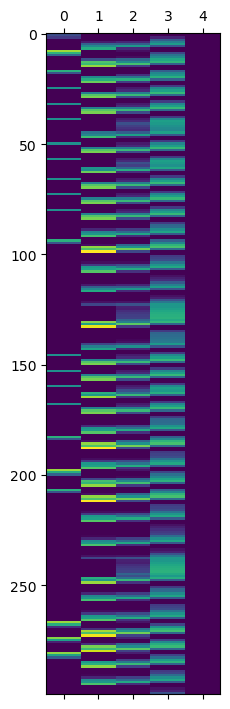

In [38]:
scale = 1.2

fig, axs = plt.subplots(1, 1, figsize=(2 * scale, 6 * scale))
cbar = axs.matshow(
    traj_data['actor_hidden'][:300, :],
    aspect='auto',
)

fig.tight_layout()

In [20]:
"""
Fixed Point Analysis for RNN Dynamics

This script finds and analyzes fixed points in trained RNN agents.
A fixed point h* satisfies: h* = f(h*, x) for a given input x.
"""

import jax
import jax.numpy as jnp
from jax import jit
import optax
import matplotlib.pyplot as plt
from typing import List, Tuple
from agents.a2c_rnn_flax import init_network_and_params


def rnn_step(hidden_state, input_vec, params, network):
    """
    Execute one RNN step using the actual network.
    
    Args:
        hidden_state: Current hidden state (hidden_size,)
        input_vec: Input vector (input_size,)
        params: Network parameters
        network: A2CRNNFlax network instance
    
    Returns:
        Next hidden state (hidden_size,)
    """
    # Add batch dimension for network compatibility
    h_batch = hidden_state[None, :]
    x_batch = input_vec[None, :]
    
    # Forward pass through RNN using apply with method argument
    h_next_batch = network.apply(
        params, h_batch, x_batch, 
        method=lambda module, h, x: module.rnn_actor(h, x)
    )
    
    return h_next_batch[0].squeeze()


def find_fixed_point(
    params,
    network,
    input_vec,
    h_init,
    max_steps=5000,
    learning_rate=0.01,
    tolerance=1e-6,
    verbose=False
) -> Tuple[jnp.ndarray, bool]:
    """
    Find a fixed point via gradient descent on ||h - f(h, x)||^2.
    
    Args:
        params: Network parameters
        network: A2CRNNFlax instance
        input_vec: Fixed input context
        h_init: Initial hidden state guess
        max_steps: Maximum optimization steps
        learning_rate: Adam learning rate
        tolerance: Convergence threshold
        verbose: Print progress
    
    Returns:
        (fixed_point, converged): Fixed point and convergence flag
    """
    def loss_fn(h):
        h_next = rnn_step(h, input_vec, params, network)
        return jnp.sum((h - h_next.squeeze()) ** 2)
    
    optimizer = optax.adam(learning_rate)
    opt_state = optimizer.init(h_init)
    h = h_init
    
    @jit
    def update(h, opt_state):
        loss, grads = jax.value_and_grad(loss_fn)(h)
        updates, opt_state = optimizer.update(grads, opt_state)
        h = optax.apply_updates(h, updates)
        return h, opt_state, loss
    
    for step in range(max_steps):
        h, opt_state, loss = update(h, opt_state)
        
        if verbose and step % 500 == 0:
            print(f"  Step {step:4d}, Loss: {loss:.8f}")
        
        if loss < tolerance:
            if verbose:
                print(f"  ✓ Converged at step {step} (loss: {loss:.8f})")
            return h, True
    
    if verbose:
        print(f"  ✗ Did not converge (final loss: {loss:.8f})")
    return h, False


def find_multiple_fixed_points(
    params,
    network,
    input_vec,
    n_attempts=20,
    hidden_dim=64,
    uniqueness_threshold=0.1,
    **kwargs
) -> List[jnp.ndarray]:
    """
    Search for multiple fixed points using random initializations.
    
    Args:
        params: Network parameters
        network: A2CRNNFlax instance
        input_vec: Fixed input context
        n_attempts: Number of random initializations
        hidden_dim: Hidden state dimension
        uniqueness_threshold: Distance threshold for duplicate detection
        **kwargs: Additional arguments for find_fixed_point
    
    Returns:
        List of unique fixed points found
    """
    fixed_points = []
    
    print(f"Searching for fixed points ({n_attempts} attempts)...\n")
    
    for i in range(n_attempts):
        # print(f"Attempt {i+1}/{n_attempts}")
        
        # Random initialization
        key = jax.random.PRNGKey(i)
        index = jax.random.randint(key, 1, 0, traj_data['actor_hidden'].shape[0])
        h_init = traj_data['actor_hidden'][index, :].squeeze()
        
        h_star, converged = find_fixed_point(
            params, network, input_vec, h_init, **kwargs
        )
        
        if converged:
            # Check uniqueness
            is_unique = all(
                jnp.linalg.norm(h_star - fp) >= uniqueness_threshold
                for fp in fixed_points
            )
            
            if is_unique:
                fixed_points.append(h_star)
                # print(f"  → New fixed point found! (Total: {len(fixed_points)})\n")
            else:
                pass
                # print(f"  → Duplicate (matches existing fixed point)\n")
    
    return fixed_points


def analyze_stability(fixed_points, input_vec, params, network):
    """
    Analyze stability of fixed points via eigenvalues of Jacobian.
    
    Args:
        fixed_points: List of fixed point states
        input_vec: Input context used to find fixed points
        params: Network parameters
        network: A2CRNNFlax instance
    
    Returns:
        List of dicts with stability info
    """
    print("\n" + "="*60)
    print("STABILITY ANALYSIS")
    print("="*60)
    
    results = []
    
    for i, fp in enumerate(fixed_points):
        # Compute Jacobian at fixed point
        jacobian = jax.jacfwd(lambda h: rnn_step(h, input_vec, params, network))(fp)
        eigenvalues = jnp.linalg.eigvals(jacobian)
        max_eig = jnp.max(jnp.abs(eigenvalues))
        
        is_stable = max_eig < 1.0
        stability_str = "Stable (attractor)" if is_stable else "Unstable (saddle)"
        
        result = {
            'fixed_point': fp,
            'eigenvalues': eigenvalues,
            'max_eigenvalue': max_eig,
            'is_stable': is_stable
        }
        results.append(result)
        
        print(f"\nFixed Point {i+1}:")
        print(f"  Max |eigenvalue|: {max_eig:.6f}")
        print(f"  Status: {stability_str}")
        print(f"  Norm: {jnp.linalg.norm(fp):.4f}")
    
    return results


def visualize_fixed_points(fixed_points, stability_results=None):
    """
    Visualize fixed points in 2D projection.
    
    Args:
        fixed_points: List of fixed point states
        stability_results: Optional stability analysis results
    """
    if len(fixed_points) == 0:
        print("No fixed points to visualize")
        return
    
    fp_array = jnp.array(fixed_points)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    
    # Plot 1: First 2 dimensions
    colors = ['green' if r['is_stable'] else 'red' 
              for r in stability_results] if stability_results else None
    
    ax1.scatter(fp_array[:, 0], fp_array[:, 1], 
                s=200, c=colors or range(len(fixed_points)),
                cmap='viridis', edgecolors='black', linewidths=2,
                alpha=0.7)
    
    for i, fp in enumerate(fp_array):
        ax1.annotate(f'{i+1}', (fp[0], fp[1]), 
                    fontsize=12, ha='center', va='center')
    
    ax1.set_xlabel('Hidden Dimension 1', fontsize=12)
    ax1.set_ylabel('Hidden Dimension 2', fontsize=12)
    ax1.set_title('Fixed Points (First 2 Dimensions)', fontsize=14)
    ax1.grid(True, alpha=0.3)
    ax1.axhline(y=0, color='k', linewidth=0.5)
    ax1.axvline(x=0, color='k', linewidth=0.5)
    
    # Plot 2: Eigenvalue spectrum
    if stability_results:
        for i, result in enumerate(stability_results):
            eigs = result['eigenvalues']
            color = 'green' if result['is_stable'] else 'red'
            ax2.scatter(eigs.real, eigs.imag, 
                       s=30, c=color, alpha=0.6, label=f'FP {i+1}')
        
        # Unit circle
        theta = jnp.linspace(0, 2*jnp.pi, 100)
        ax2.plot(jnp.cos(theta), jnp.sin(theta), 'k--', 
                linewidth=2, label='Unit circle', alpha=0.5)
        
        ax2.set_xlabel('Real Part', fontsize=12)
        ax2.set_ylabel('Imaginary Part', fontsize=12)
        ax2.set_title('Eigenvalue Spectrum', fontsize=14)
        ax2.grid(True, alpha=0.3)
        ax2.axhline(y=0, color='k', linewidth=0.5)
        ax2.axvline(x=0, color='k', linewidth=0.5)
        ax2.legend(fontsize=10)
        ax2.set_aspect('equal')
    
    plt.tight_layout()
    plt.show()


# ============================================================================
# MAIN USAGE EXAMPLE
# ============================================================================

def find_and_plot_fixed_points(input_vec, n_attempts=100):
    # Define input context
    # Input format: [obs(4), prev_action_onehot(2), prev_reward(1)]
    input_dim = CONFIG['obs_size'] + CONFIG['action_size'] + 1
    
    # Or try specific contexts:
    # sample_input = jnp.array([1, 0, 0, 0,  # obs (one-hot)
    #                           1, 0,         # prev_action (one-hot)
    #                           0.5,          # prev_reward
    #                           0.8])         # env_quality
    
    print(f"Input dimension: {input_dim}")
    
    # Find fixed points
    fixed_points = find_multiple_fixed_points(
        params=params,
        network=network,
        input_vec=input_vec,
        n_attempts=n_attempts,
        hidden_dim=CONFIG['hidden_size'],
        max_steps=10000,
        learning_rate=0.01,
        tolerance=1e-6,
        verbose=False
    )
    
    print(f"\n{'='*60}")
    print(f"SUMMARY: Found {len(fixed_points)} unique fixed points")
    print(f"{'='*60}")
    
    # Analyze stability
    if fixed_points:
        stability_results = analyze_stability(
            fixed_points, sample_input, params, network
        )
        
        # Visualize
        visualize_fixed_points(fixed_points, stability_results)
    else:
        print("\nNo fixed points found. Try:")
        print("  - Different input contexts")
        print("  - More random initializations")
        print("  - Different learning rates or tolerances")
    return fixed_points

In [21]:
from typing import Tuple


def rnn_step_batch(hidden_states, input_vec, params, network):
    """
    Execute one RNN step for a batch of hidden states.
    
    Args:
        hidden_states: Batch of hidden states (batch_size, hidden_size)
        input_vec: Input vector (input_size,) - same for all
        params: Network parameters
        network: A2CRNNFlax network instance
    
    Returns:
        Next hidden states (batch_size, hidden_size)
    """
    batch_size = hidden_states.shape[0]
    # Repeat input for batch
    x_batch = jnp.tile(input_vec[None, :], (batch_size, 1))
    
    # Forward pass through RNN
    h_next_batch = network.apply(
        params, hidden_states, x_batch, 
        method=lambda module, h, x: module.rnn_actor(h, x)
    )
    
    return h_next_batch[0].squeeze()


def find_fixed_points_batch(
    params,
    network,
    input_vec,
    h_inits,
    max_steps=5000,
    learning_rate=0.01,
    tolerance=1e-6,
    verbose=False
) -> Tuple[jnp.ndarray, jnp.ndarray]:
    """
    Find fixed points for multiple initializations in parallel.
    
    Args:
        params: Network parameters
        network: A2CRNNFlax instance
        input_vec: Fixed input context
        h_inits: Initial hidden states (batch_size, hidden_size)
        max_steps: Maximum optimization steps
        learning_rate: Adam learning rate
        tolerance: Convergence threshold
        verbose: Print progress
    
    Returns:
        (fixed_points, converged): Arrays of shape (batch_size, hidden_size) and (batch_size,)
    """
    batch_size = h_inits.shape[0]
    
    # Define loss function for a single hidden state
    def loss_fn_single(h):
        h_next = rnn_step_batch(h[None, :], input_vec, params, network).squeeze()
        return jnp.sum((h - h_next) ** 2)
    
    # Vectorize loss and gradient computation across batch
    loss_and_grad_fn = jax.vmap(jax.value_and_grad(loss_fn_single))
    
    optimizer = optax.adam(learning_rate)
    opt_state = optimizer.init(h_inits)
    h_batch = h_inits
    
    @jit
    def update(h_batch, opt_state):
        losses, grads = loss_and_grad_fn(h_batch)
        updates, opt_state = optimizer.update(grads, opt_state)
        h_batch = optax.apply_updates(h_batch, updates)
        return h_batch, opt_state, losses
    
    converged = jnp.zeros(batch_size, dtype=bool)
    
    for step in range(max_steps):
        h_batch, opt_state, losses = update(h_batch, opt_state)
        
        # Check convergence for each sample
        newly_converged = (losses < tolerance) & (~converged)
        converged = converged | newly_converged
        
        if verbose and step % 20000 == 0:
            n_converged = jnp.sum(converged)
            print(f"  Step {step:4d}, Converged: {n_converged}/{batch_size}, Mean loss: {jnp.mean(losses):.8f}")
        
        if jnp.all(converged):
            if verbose:
                print(f"  ✓ All converged at step {step}")
            break
    
    if verbose:
        n_converged = jnp.sum(converged)
        print(f"  Final: {n_converged}/{batch_size} converged")
    
    return h_batch, converged


def filter_unique_fixed_points(
    fixed_points,
    converged,
    uniqueness_threshold=0.1
):
    """
    Filter out duplicate fixed points.
    
    Args:
        fixed_points: Array of fixed points (batch_size, hidden_size)
        converged: Boolean array indicating convergence (batch_size,)
        uniqueness_threshold: Distance threshold for duplicates
    
    Returns:
        Array of unique fixed points
    """
    # Only consider converged points
    fps = fixed_points[converged]
    
    if len(fps) == 0:
        return jnp.array([])
    
    unique_fps = [fps[0]]
    
    for fp in fps[1:]:
        is_unique = all(
            jnp.linalg.norm(fp - ufp) >= uniqueness_threshold
            for ufp in unique_fps
        )
        if is_unique:
            unique_fps.append(fp)
    
    return jnp.array(unique_fps)


def analyze_stability_batch(fixed_points, input_vec, params, network):
    """
    Analyze stability of fixed points via eigenvalues of Jacobian.
    
    Args:
        fixed_points: Array of fixed points (n_points, hidden_size)
        input_vec: Input context
        params: Network parameters
        network: A2CRNNFlax instance
    
    Returns:
        List of eigenvalue arrays
    """
    def compute_jacobian_eigs(fp):
        jacobian = jax.jacfwd(
            lambda h: rnn_step_batch(h[None, :], input_vec, params, network).squeeze()
        )(fp)
        return jnp.linalg.eigvals(jacobian)
    
    # Vectorize over fixed points
    all_eigenvalues = jax.vmap(compute_jacobian_eigs)(fixed_points)
    return all_eigenvalues


def plot_eigenspectra_grid(eigenvalues_list, n_plots=9):
    """
    Plot eigenspectra in a 3x3 grid.
    
    Args:
        eigenvalues_list: Array of eigenvalues (n_points, hidden_size)
        n_plots: Number of plots (default 9 for 3x3 grid)
    """
    n_fps = min(len(eigenvalues_list), n_plots)
    
    if n_fps == 0:
        print("No fixed points to plot")
        return
    
    fig, axes = plt.subplots(3, 3, figsize=(5, 5))
    axes = axes.flatten()
    
    # Unit circle
    theta = jnp.linspace(0, 2*jnp.pi, 100)
    unit_circle_x = jnp.cos(theta)
    unit_circle_y = jnp.sin(theta)
    
    for i in range(9):
        ax = axes[i]
        
        if i < n_fps:
            eigs = eigenvalues_list[i]
            max_eig = jnp.max(jnp.abs(eigs))
            is_stable = max_eig < 1.0
            color = 'green' if is_stable else 'red'
            
            # Plot eigenvalues
            ax.scatter(eigs.real, eigs.imag, s=30, c=color, alpha=0.6)
            
            # Plot unit circle
            ax.plot(unit_circle_x, unit_circle_y, 'k--', linewidth=1, alpha=0.5)
            
            ax.set_aspect('equal')
            ax.set_xlabel('Real')
            ax.set_ylabel('Imag')
        else:
            ax.axis('off')
    
    plt.tight_layout()
    format_plot(axes)
    plt.show()


# ============================================================================
# MAIN USAGE
# ============================================================================

def find_and_plot_fixed_points(input_vec, traj_data, params, network, CONFIG, n_attempts=100, tol=1e-7):
    """
    Find fixed points and plot their eigenspectra.
    
    Args:
        input_vec: Input context vector
        traj_data: Dictionary with 'actor_hidden' trajectory data
        params: Network parameters
        network: Network instance
        CONFIG: Config dictionary with 'hidden_size'
        n_attempts: Number of random initializations
    """
    print(f"Searching for fixed points ({n_attempts} attempts)...\n")
    
    # Create batch of random initializations from trajectory
    key = jax.random.PRNGKey(42)
    indices = jax.random.randint(key, (n_attempts,), 0, traj_data['actor_hidden'].shape[0])
    h_inits = traj_data['actor_hidden'][indices, :]
    
    # Find fixed points in batch
    fixed_points, converged = find_fixed_points_batch(
        params=params,
        network=network,
        input_vec=input_vec,
        h_inits=h_inits,
        max_steps=60000,
        learning_rate=0.001,
        tolerance=tol,
        verbose=True
    )
    
    # Filter unique fixed points
    unique_fps = filter_unique_fixed_points(
        fixed_points, converged, uniqueness_threshold=0.1
    )
    
    print(f"\n{'='*60}")
    print(f"SUMMARY: Found {len(unique_fps)} unique fixed points")
    print(f"{'='*60}\n")
    
    if len(unique_fps) > 0:
        # Analyze stability
        eigenvalues = analyze_stability_batch(unique_fps, input_vec, params, network)

        print(eigenvalues.shape)
        
        # Plot first 9 eigenspectra
        plot_eigenspectra_grid(eigenvalues, n_plots=9)
        plot_eigenvalue_real_histograms(eigenvalues, bin_size=0.05, n_plots=9)
    else:
        print("No fixed points found.")

    return fixed_points[converged,:]


def run_states_forward(
    h_inits,
    input_vec,
    params,
    network,
    n_steps=100
):
    """
    Run multiple initial hidden states forward through the RNN.
    
    Args:
        h_inits: Initial hidden states (batch_size, hidden_size)
        input_vec: Fixed input context (input_size,)
        params: Network parameters
        network: A2CRNNFlax instance
        n_steps: Number of forward steps to simulate
    
    Returns:
        trajectories: Array of shape (n_steps, batch_size, hidden_size)
    """
    batch_size = h_inits.shape[0]
    hidden_size = h_inits.shape[1]
    
    # Initialize trajectory storage
    trajectories = jnp.zeros((n_steps, batch_size, hidden_size))
    trajectories = trajectories.at[0].set(h_inits)
    
    # Run forward
    h_current = h_inits
    for t in range(1, n_steps):
        h_current = rnn_step_batch(h_current, input_vec, params, network)
        trajectories = trajectories.at[t].set(h_current)
    
    return trajectories

def plot_eigenvalue_real_histograms(
    eigenvalues_list,
    bin_size=0.1,
    n_plots=9,
    figsize=(12, 9)
):
    """
    Plot histograms of real parts of eigenvalues as connected scatter plots.
    
    Args:
        eigenvalues_list: Array of eigenvalues (n_points, hidden_size)
        bin_size: Width of histogram bins (default: 0.1)
        n_plots: Number of plots to show (default: 9 for 3x3 grid)
        figsize: Figure size
    """
    n_fps = min(len(eigenvalues_list), n_plots)
    
    if n_fps == 0:
        print("No fixed points to plot")
        return
    
    fig, axes = plt.subplots(3, 3, figsize=figsize)
    axes = axes.flatten()
    
    for i in range(9):
        ax = axes[i]
        
        if i < n_fps:
            eigs = eigenvalues_list[i]
            real_parts = eigs.real
            
            # Determine bin edges
            min_real = jnp.floor(jnp.min(real_parts) / bin_size) * bin_size
            max_real = jnp.ceil(jnp.max(real_parts) / bin_size) * bin_size
            bins = jnp.arange(min_real, max_real + bin_size, bin_size)
            
            # Compute histogram
            counts, _ = jnp.histogram(real_parts, bins=bins)
            bin_centers = bins[:-1] + bin_size / 2
            
            # Determine stability
            max_eig = jnp.max(jnp.abs(eigs))
            is_stable = max_eig < 1.0
            color = 'green' if is_stable else 'red'
            
            # Plot as connected scatter
            ax.plot(bin_centers, counts, 'o-', color=color, 
                   linewidth=2, markersize=6, alpha=0.7)
            
            # Add vertical line at x=0
            ax.axvline(x=0, color='black', linestyle='--', 
                      linewidth=1, alpha=0.3)
            
            # Add vertical line at x=1
            ax.axvline(x=1, color='red', linestyle='--', 
                      linewidth=1, alpha=0.3, label='Re=1')
            
            ax.set_xlabel('Real Part')
            ax.set_ylabel('Frequency')
            ax.set_title(f'FP {i+1} ({"Stable" if is_stable else "Unstable"})')
            ax.grid(True, alpha=0.3)
            
        else:
            ax.axis('off')
    
    plt.suptitle('Eigenvalue Real Part Distributions', fontsize=14, y=1.00)
    plt.tight_layout()

In [22]:
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
from aux_funcs import format_plot, format_pc_plot

def plot_trajectory(fixed_points, start=100, end=150):
    scale = 1.2
    fig, axs = plt.subplots(2, 2, figsize=(4.3 * scale, 4 * scale))

    # define a colormap and normalization for time
    cmap = plt.cm.viridis
    norm = Normalize(vmin=0, vmax=end-start)

    for k in np.arange(0, 8, 2):
        k_x, k_y = int(k/4), int(k/2) % 2

        cbar = axs[k_x, k_y].scatter(
            pc_activities.T[k, :],
            pc_activities.T[k+1, :],
            s=0.1,
            color='#d7d9d7',
            alpha=1,
        )

        for fp in pca.transform(fixed_points):
            axs[k_x, k_y].scatter(
                fp[k],
                fp[k+1],
                s=5,
                color='red',
            )

    fig.tight_layout()
    format_pc_plot(axs)

In [23]:
# Configuration
CONFIG = {
    'hidden_size': 64,
    'action_size': 2,
    'obs_size': 4,
    'rnn_type': 'GRU',  # or 'VANILLA'
    'var_noise': 0.0,
}

# Define input context
# Input format: [obs(4), prev_action_onehot(2), prev_reward(1)]
input_dim = CONFIG['obs_size'] + CONFIG['action_size'] + 1

In [24]:
# Example: neutral context
input_vec = jnp.zeros(input_dim)
input_vec = input_vec.at[5].set(1)

fixed_points = find_and_plot_fixed_points(input_vec, traj_data, params, network, CONFIG, n_attempts=2000)
print(fixed_points.shape)
plot_trajectory(fixed_points)

Searching for fixed points (2000 attempts)...



InvalidRngError: rnn_actor needs PRNG for "noise" (https://flax.readthedocs.io/en/latest/api_reference/flax.errors.html#flax.errors.InvalidRngError)

(2000, 200, 64)


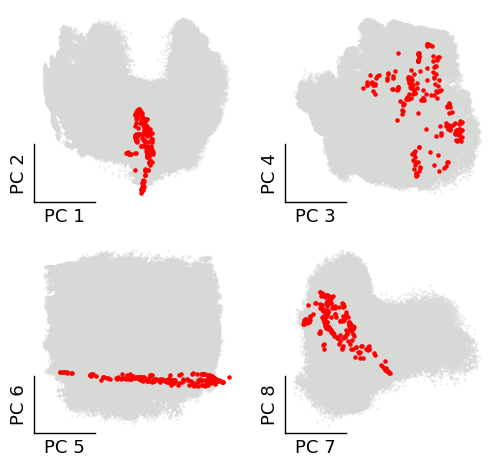

In [45]:
# Example: neutral context
input_vec = jnp.zeros(input_dim)
input_vec = input_vec.at[5].set(1)

key = jax.random.PRNGKey(42)
indices = jax.random.randint(key, (200,), 0, traj_data['actor_hidden'].shape[0])
h_inits = traj_data['actor_hidden'][indices, :]

trajectories = run_states_forward(
    h_inits,
    input_vec,
    params,
    network,
    n_steps=2000,
)

print(trajectories.shape)

plot_trajectory(trajectories[-1, ...])

Searching for fixed points (2000 attempts)...

  Step    0, Converged: 0/2000, Mean loss: 2.38138390
  Step 20000, Converged: 5/2000, Mean loss: 0.00000306
  Step 40000, Converged: 52/2000, Mean loss: 0.00000148
  Final: 124/2000 converged

SUMMARY: Found 124 unique fixed points



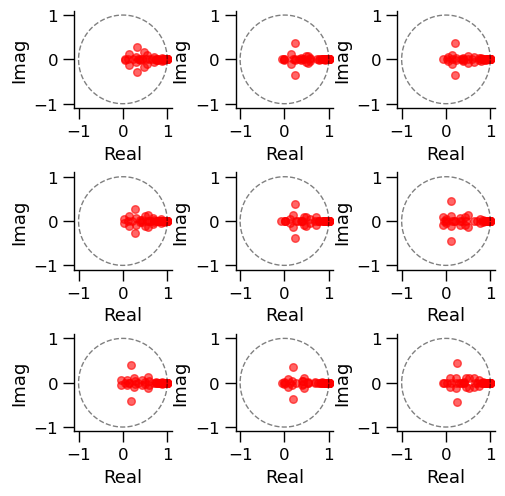

(124, 64)


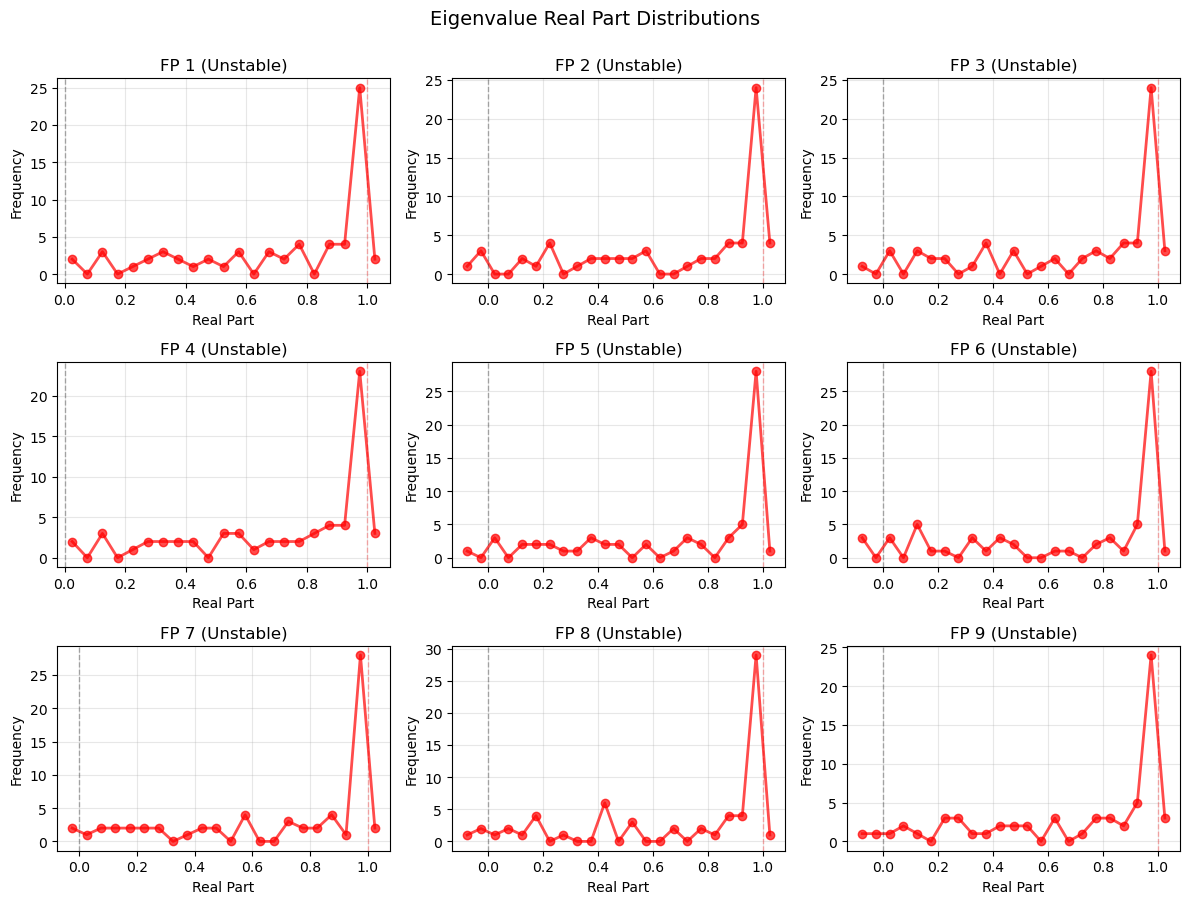

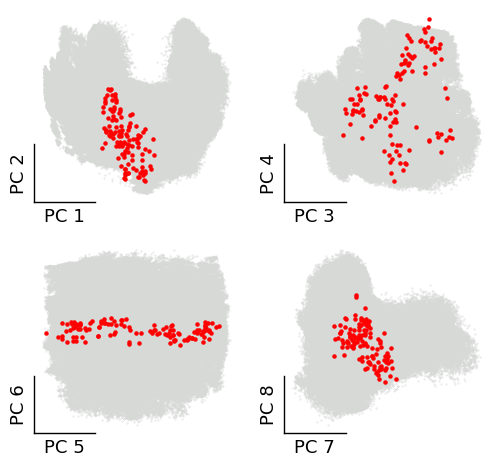

In [68]:
# Example: neutral context
input_vec = jnp.zeros(input_dim)
input_vec = input_vec.at[0].set(1)
input_vec = input_vec.at[5].set(1)

fixed_points = find_and_plot_fixed_points(input_vec, traj_data, params, network, CONFIG, n_attempts=2000)
print(fixed_points.shape)
plot_trajectory(fixed_points, 0, 2000)

(2000, 200, 64)


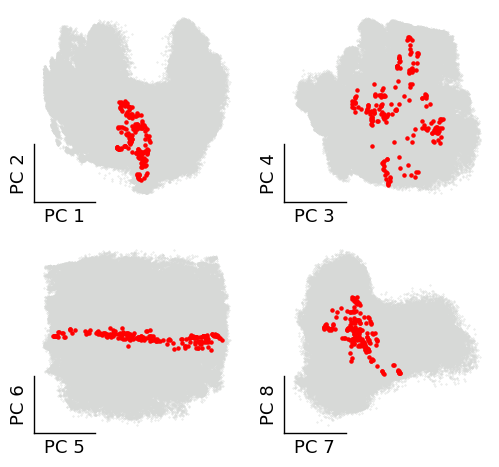

In [46]:
# Example: neutral context
input_vec = jnp.zeros(input_dim)
input_vec = input_vec.at[0].set(1)
input_vec = input_vec.at[5].set(1)

key = jax.random.PRNGKey(42)
indices = jax.random.randint(key, (200,), 0, traj_data['actor_hidden'].shape[0])
h_inits = traj_data['actor_hidden'][indices, :]

trajectories = run_states_forward(
    h_inits,
    input_vec,
    params,
    network,
    n_steps=2000
)

print(trajectories.shape)

plot_trajectory(trajectories[-1, ...])

Searching for fixed points (3000 attempts)...

ERROR! Session/line number was not unique in database. History logging moved to new session 91
  Step    0, Converged: 0/3000, Mean loss: 2.37598896
  Step 20000, Converged: 0/3000, Mean loss: 0.00000594
  Step 40000, Converged: 16/3000, Mean loss: 0.00000266
  Final: 61/3000 converged

SUMMARY: Found 61 unique fixed points

(61, 64)


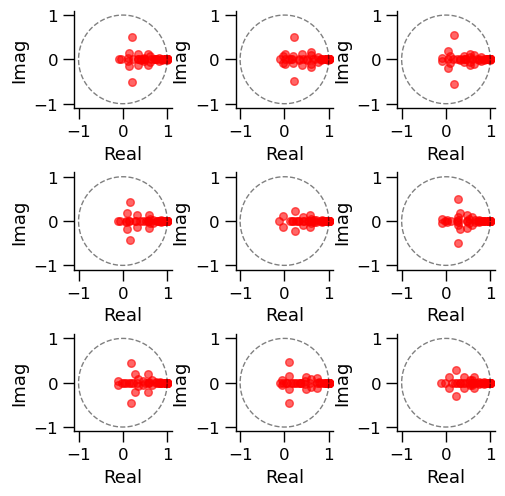

(61, 64)


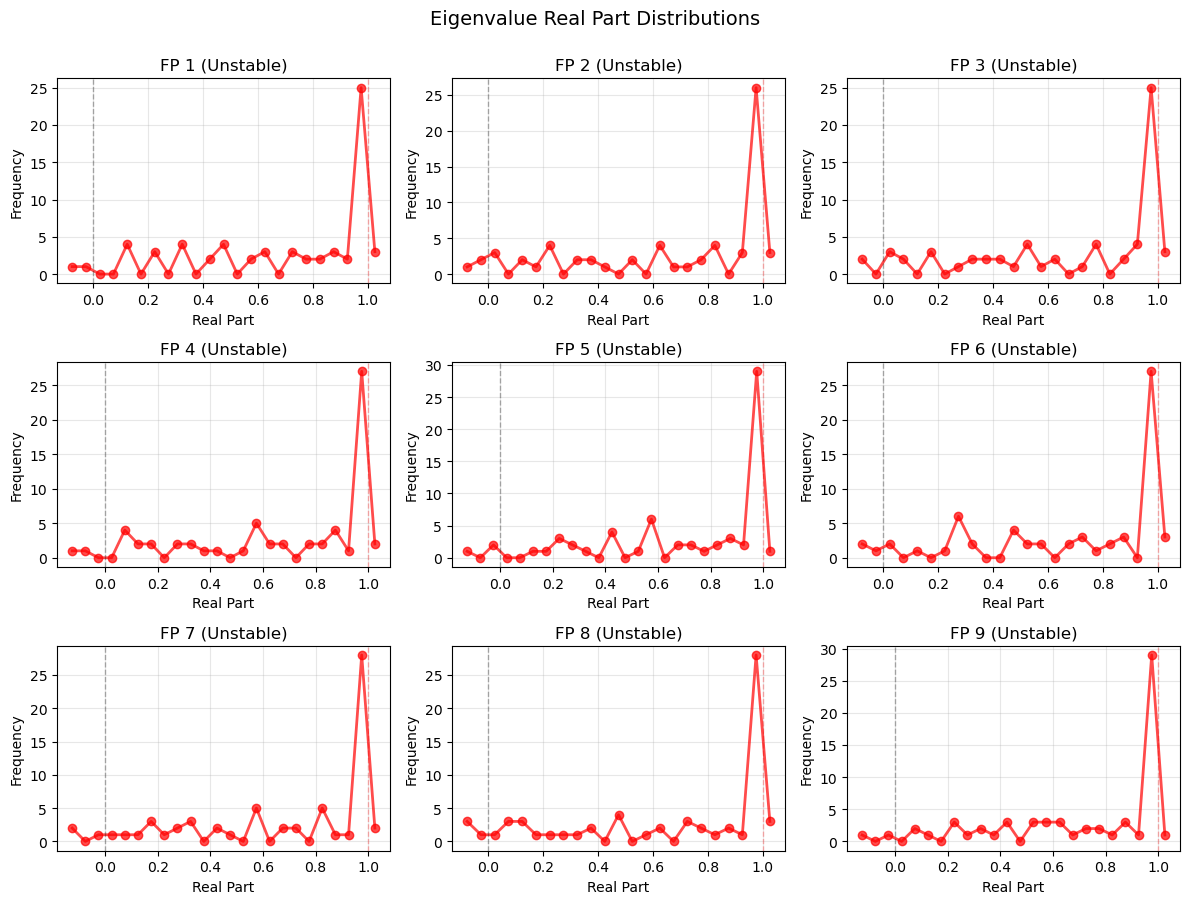

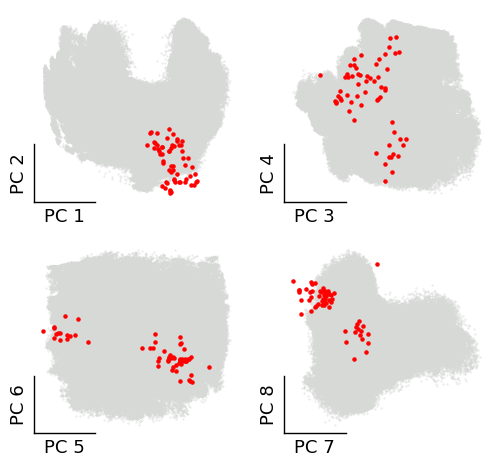

In [40]:
# Example: neutral context
input_vec = jnp.zeros(input_dim)
input_vec = input_vec.at[0].set(1)
input_vec = input_vec.at[1].set(1)
input_vec = input_vec.at[5].set(1)

fixed_points = find_and_plot_fixed_points(input_vec, traj_data, params, network, CONFIG, n_attempts=3000, tol=0.2e-6)
print(fixed_points.shape)
plot_trajectory(fixed_points)

(2000, 200, 64)


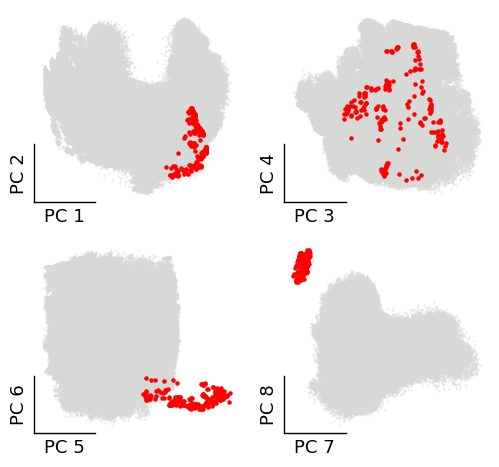

In [36]:
# Example: neutral context
input_vec = jnp.zeros(input_dim)
input_vec = input_vec.at[0].set(1)
input_vec = input_vec.at[1].set(1)
input_vec = input_vec.at[5].set(1)

key = jax.random.PRNGKey(42)
indices = jax.random.randint(key, (200,), 0, traj_data['actor_hidden'].shape[0])
h_inits = traj_data['actor_hidden'][indices, :]

trajectories = run_states_forward(
    h_inits,
    input_vec,
    params,
    network,
    n_steps=2000
)

print(trajectories.shape)

plot_trajectory(trajectories[-5, :, :])

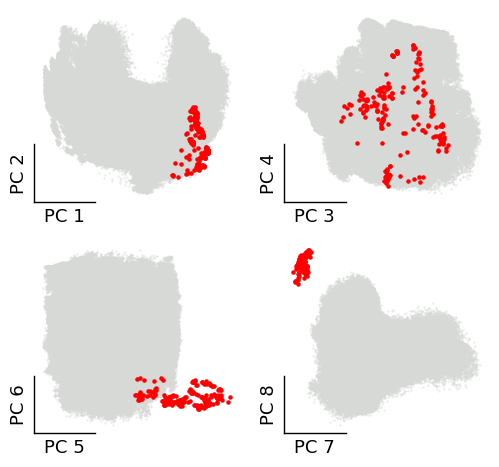

In [38]:
plot_trajectory(trajectories[-500, :, :])

Searching for fixed points (3000 attempts)...

  Step    0, Converged: 0/3000, Mean loss: 3.12153912
  Step 20000, Converged: 0/3000, Mean loss: 0.00000611
  Step 40000, Converged: 26/3000, Mean loss: 0.00000269
  Final: 81/3000 converged

SUMMARY: Found 81 unique fixed points

(81, 64)


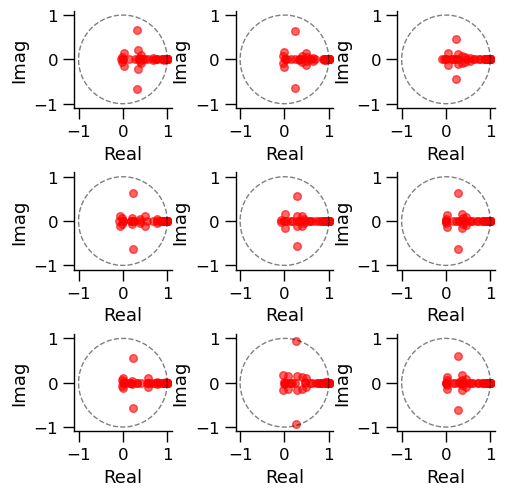

(81, 64)


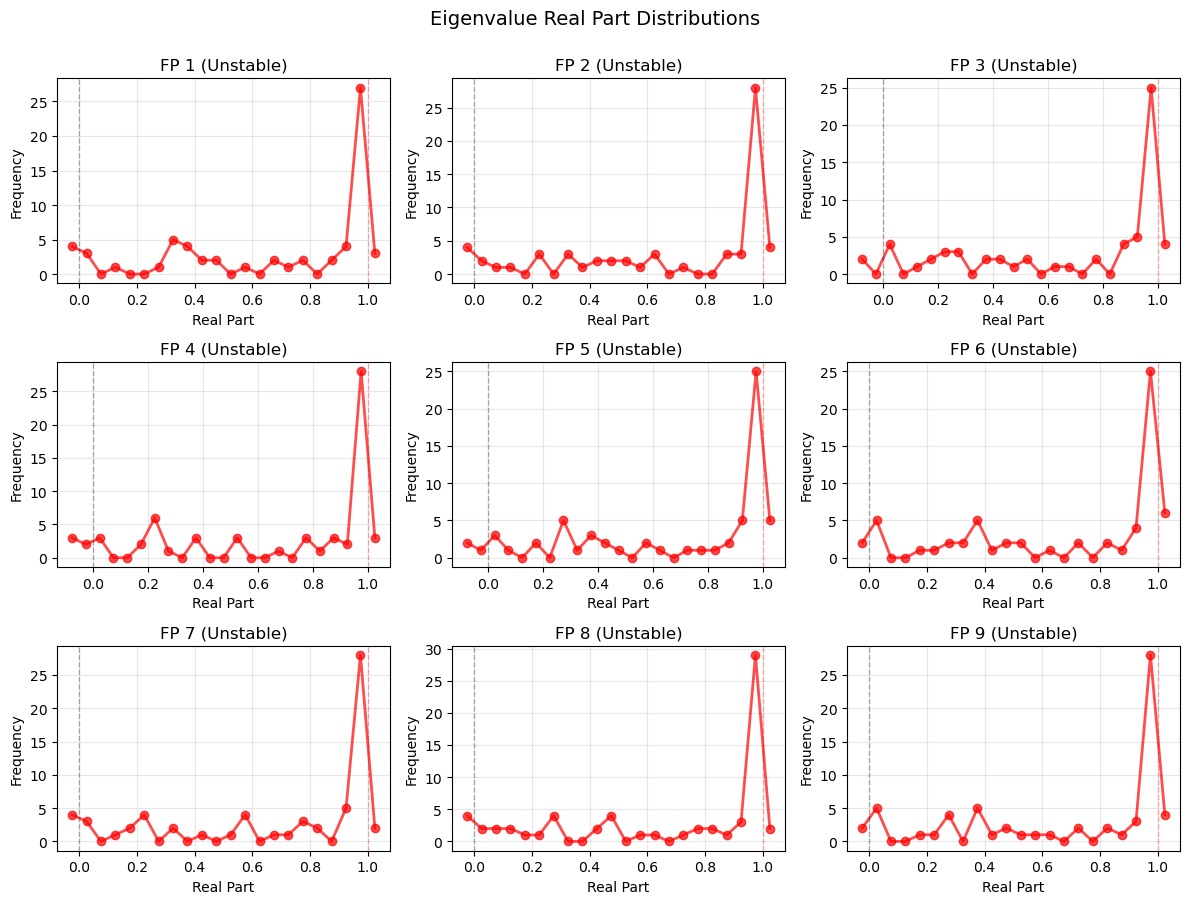

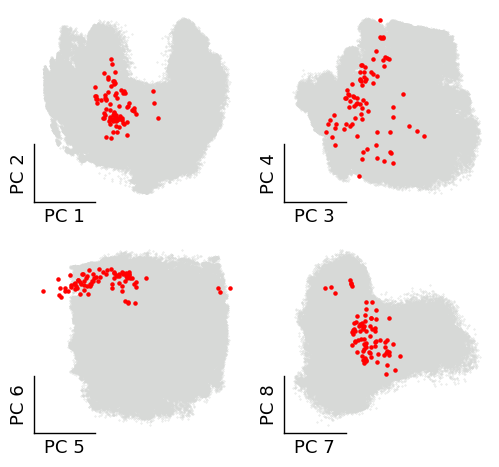

In [41]:
# Example: neutral context
input_vec = jnp.zeros(input_dim)
input_vec = input_vec.at[0].set(1)
input_vec = input_vec.at[1].set(1)
input_vec = input_vec.at[4].set(1)

fixed_points = find_and_plot_fixed_points(input_vec, traj_data, params, network, CONFIG, n_attempts=3000, tol=0.2e-6)
print(fixed_points.shape)
plot_trajectory(fixed_points)

Searching for fixed points (3000 attempts)...

  Step    0, Converged: 0/3000, Mean loss: 3.42236590
  Step 20000, Converged: 39/3000, Mean loss: 0.00000719
  Step 40000, Converged: 336/3000, Mean loss: 0.00000264
  Final: 922/3000 converged

SUMMARY: Found 918 unique fixed points

(918, 64)


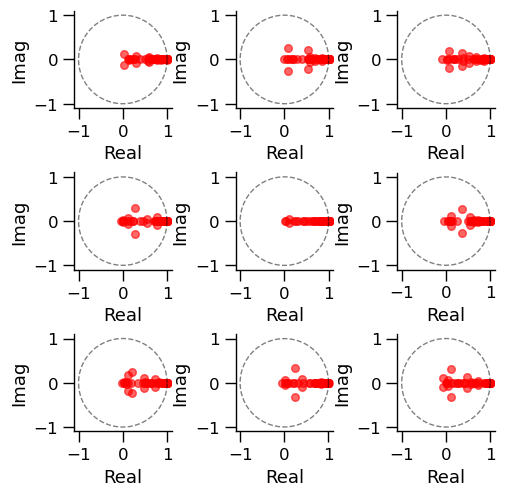

(922, 64)


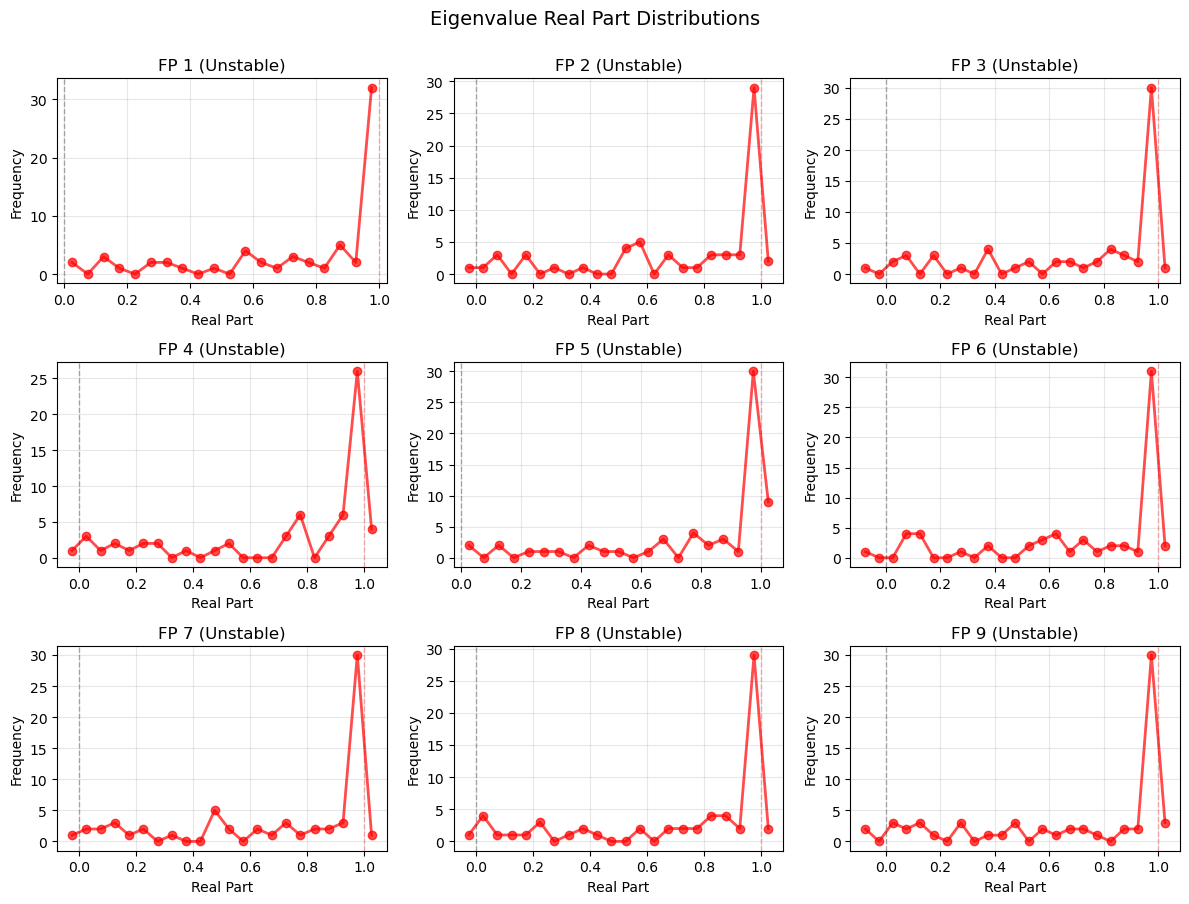

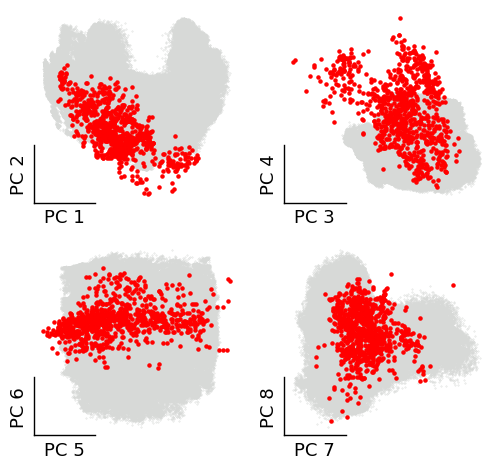

In [43]:
# Example: neutral context
input_vec = jnp.zeros(input_dim)
input_vec = input_vec.at[0].set(1)
input_vec = input_vec.at[1].set(1)
input_vec = input_vec.at[5].set(1)
input_vec = input_vec.at[6].set(1)

fixed_points = find_and_plot_fixed_points(input_vec, traj_data, params, network, CONFIG, n_attempts=3000, tol=5e-7)
print(fixed_points.shape)
plot_trajectory(fixed_points)

(2000, 200, 64)


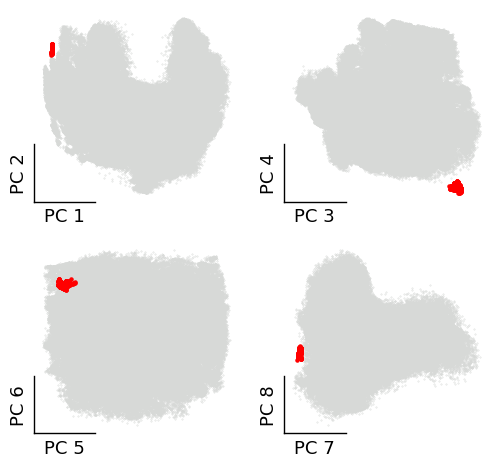

In [80]:
# Example: neutral context
input_vec = jnp.zeros(input_dim)
input_vec = input_vec.at[0].set(1)
input_vec = input_vec.at[1].set(1)
input_vec = input_vec.at[5].set(1)
input_vec = input_vec.at[6].set(1)

key = jax.random.PRNGKey(42)
indices = jax.random.randint(key, (200,), 0, traj_data['actor_hidden'].shape[0])
h_inits = traj_data['actor_hidden'][indices, :]

trajectories = run_states_forward(
    h_inits,
    input_vec,
    params,
    network,
    n_steps=2000
)

print(trajectories.shape)

plot_trajectory(trajectories[-1, ...])

Searching for fixed points (2000 attempts)...

  Step    0, Converged: 0/2000, Mean loss: 4.14719343
  Step 20000, Converged: 0/2000, Mean loss: 0.00000824
  Step 40000, Converged: 0/2000, Mean loss: 0.00000306
  Final: 2/2000 converged

SUMMARY: Found 2 unique fixed points



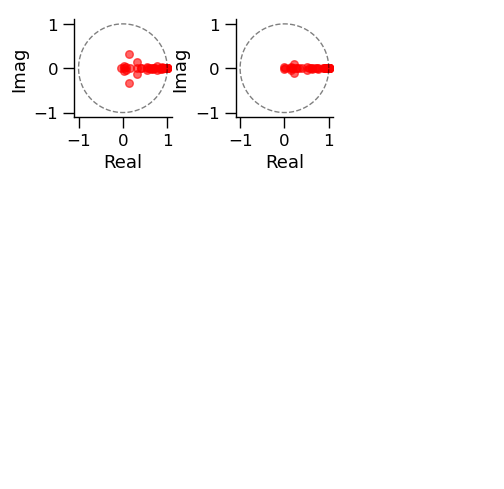

(64,)
(64,)
(2, 64)


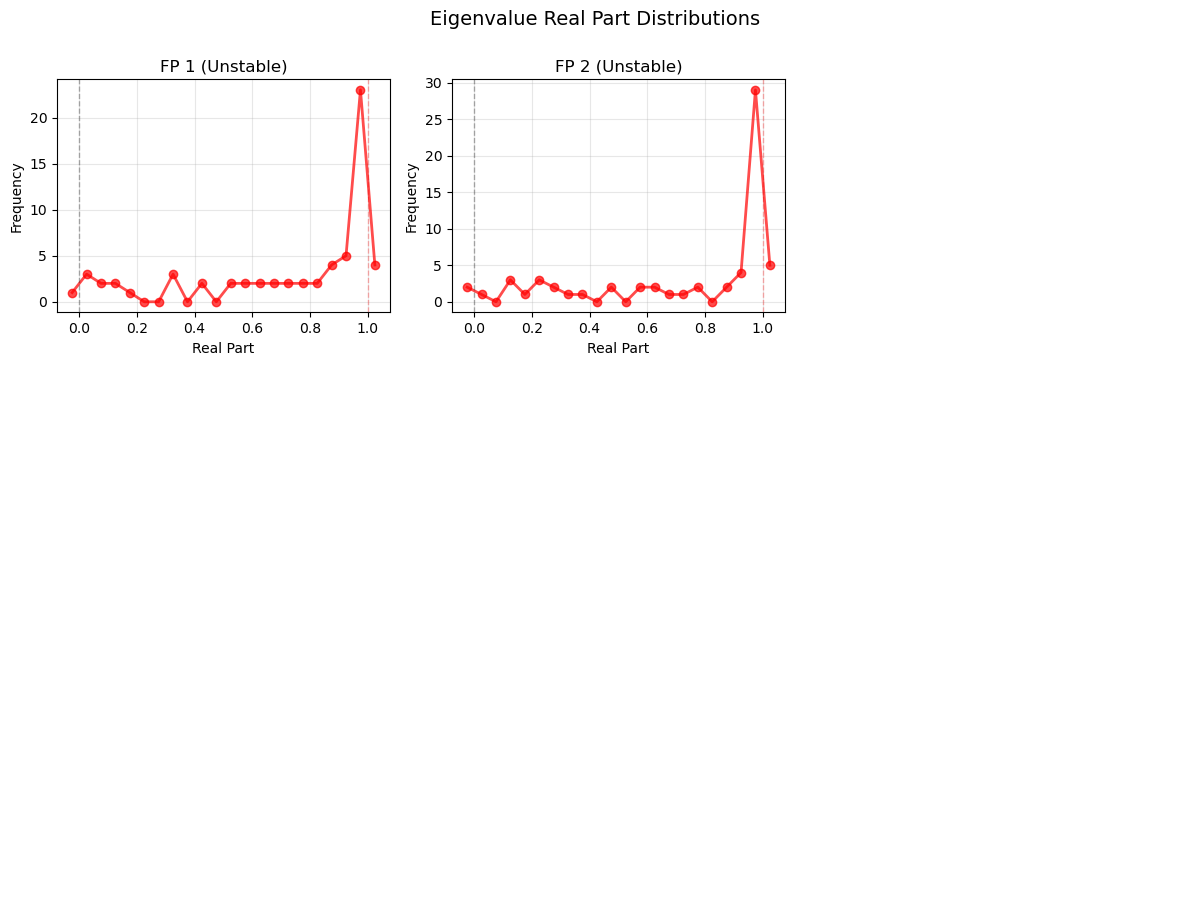

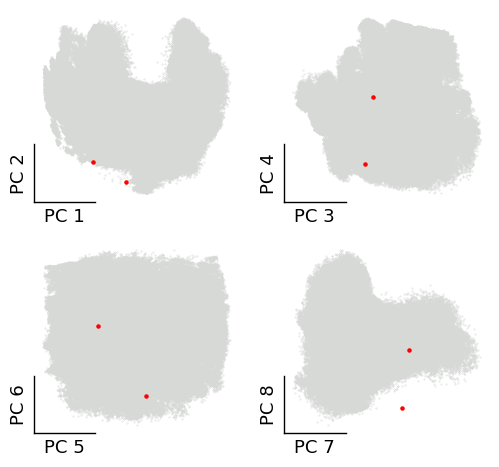

In [82]:
# Example: neutral context
input_vec = jnp.zeros(input_dim)
input_vec = input_vec.at[0].set(1)
input_vec = input_vec.at[2].set(1)
input_vec = input_vec.at[5].set(1)
input_vec = input_vec.at[6].set(1)

fixed_points = find_and_plot_fixed_points(input_vec, traj_data, params, network, CONFIG, n_attempts=2000)
print(fixed_points.shape)
plot_trajectory(fixed_points)

(2000, 200, 64)


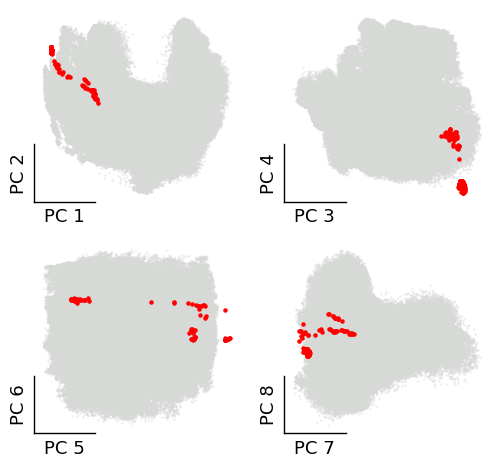

In [84]:
# Example: neutral context
input_vec = jnp.zeros(input_dim)
input_vec = input_vec.at[0].set(1)
input_vec = input_vec.at[2].set(1)
input_vec = input_vec.at[5].set(1)
input_vec = input_vec.at[6].set(1)

key = jax.random.PRNGKey(42)
indices = jax.random.randint(key, (200,), 0, traj_data['actor_hidden'].shape[0])
h_inits = traj_data['actor_hidden'][indices, :]

trajectories = run_states_forward(
    h_inits,
    input_vec,
    params,
    network,
    n_steps=2000
)

print(trajectories.shape)

plot_trajectory(trajectories[-1, ...])

Searching for fixed points (2000 attempts)...

  Step    0, Converged: 0/2000, Mean loss: 3.55903077
  Step 20000, Converged: 0/2000, Mean loss: 0.00000633
  Step 40000, Converged: 2/2000, Mean loss: 0.00000217
  Final: 8/2000 converged

SUMMARY: Found 8 unique fixed points



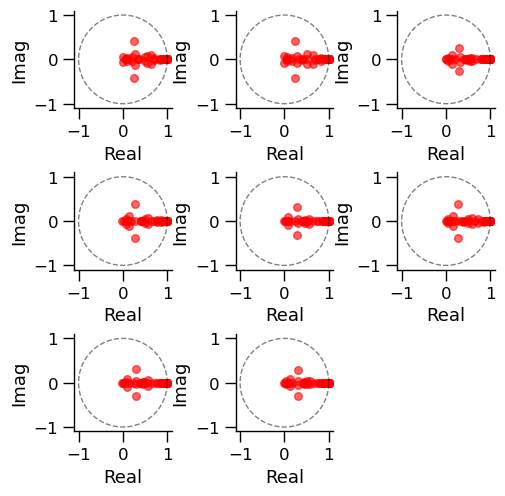

(64,)
(64,)
(64,)
(64,)
(64,)
(64,)
(64,)
(64,)
(8, 64)


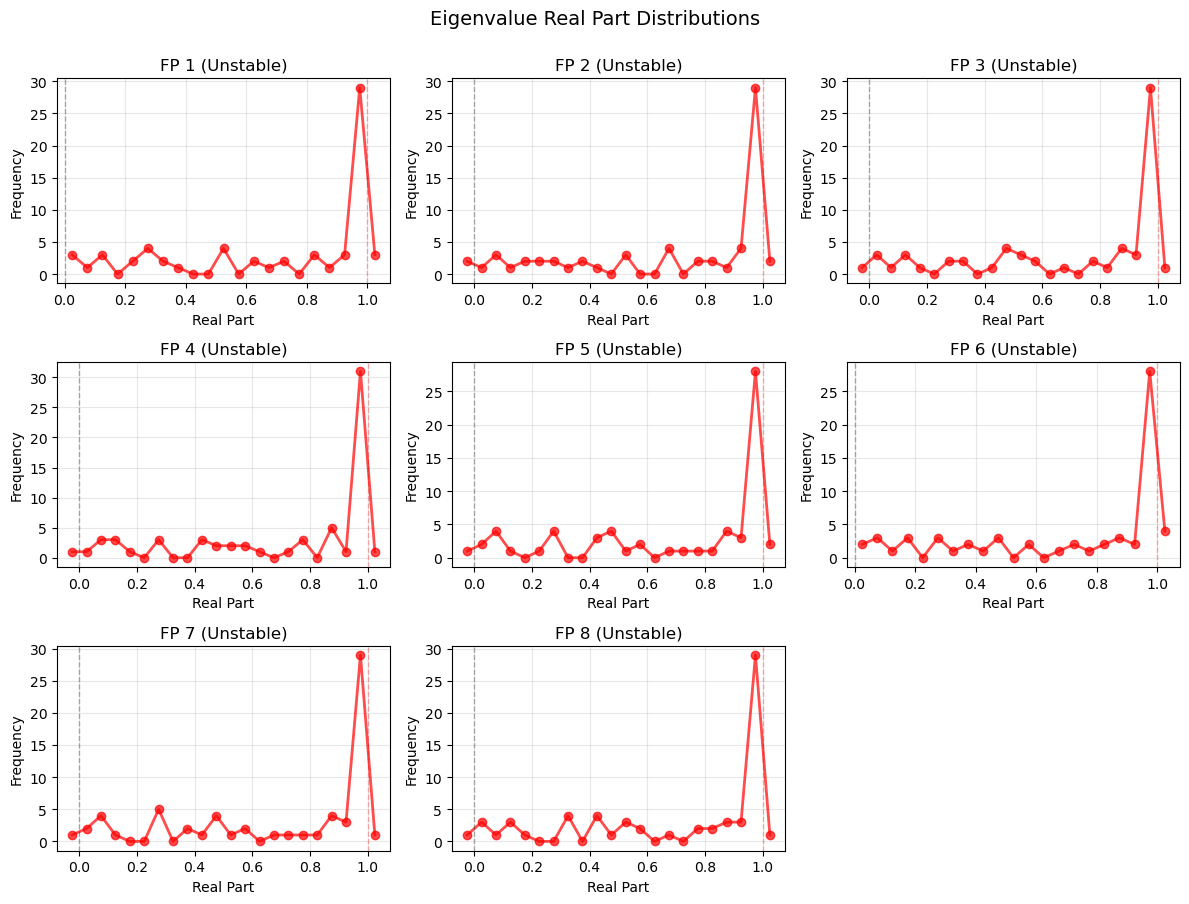

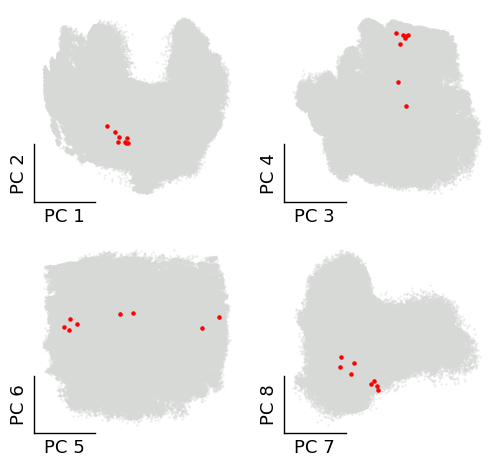

In [83]:
# Example: neutral context
input_vec = jnp.zeros(input_dim)
input_vec = input_vec.at[0].set(1)
input_vec = input_vec.at[3].set(1)
input_vec = input_vec.at[5].set(1)
input_vec = input_vec.at[6].set(1)

fixed_points = find_and_plot_fixed_points(input_vec, traj_data, params, network, CONFIG, n_attempts=2000)
print(fixed_points.shape)
plot_trajectory(fixed_points)

In [ ]:
# Example: neutral context
input_vec = jnp.zeros(input_dim)
input_vec = input_vec.at[0].set(1)
input_vec = input_vec.at[2].set(1)
input_vec = input_vec.at[5].set(1)
input_vec = input_vec.at[6].set(1)

fixed_points = find_and_plot_fixed_points(input_vec, traj_data, params, network, CONFIG, n_attempts=500)
print(fixed_points.shape)
plot_trajectory(0, 2000)

In [ ]:
# Example: neutral context
input_vec = jnp.zeros(input_dim)
input_vec = input_vec.at[0].set(1)
input_vec = input_vec.at[1].set(1)
input_vec = input_vec.at[5].set(1)

fixed_points = find_and_plot_fixed_points(input_vec, n_attempts=100)

plot_trajectory(0, 2000)

In [ ]:
# Example: neutral context
input_vec = jnp.zeros(input_dim)
input_vec = input_vec.at[0].set(1)
input_vec = input_vec.at[1].set(1)
input_vec = input_vec.at[5].set(1)
input_vec = input_vec.at[6].set(1)

fixed_points = find_and_plot_fixed_points(input_vec, n_attempts=100)

plot_trajectory(0, 2000)